In [1]:
from cirq_sic import *

## Performing a SIC

Use `WHPOVMOnStatesTask`!

You can choose `run_type` to be `clean` (no noise), `noisy` (with hardware noise model), or `real` (on the hardware).

`get_wh_qubits` will pick qubits for you (right now it always picks them same).

The optimizer can be set to `cirq` (just enough to conform to the hardware) or `bqskit_local_n` where `n` is the level of optimization (1, 2, 3, or 4), and if you want to run multiple bqskit compiles at the same time change `local` to `server`. In that case, make sure to run `bqskit-manager` and `bqskit-server localhost` first.

Right now `d` has to be a power of 2: working out some kinks for arbitrary `d`.

`fiducial` can be any normalized numpy vector. Make sure to give it a unique descriptive name in `fiducial_description`. Alternatively, you can provide `fiducial_circuit` which must be a `cirq.Circuit`.

`wh_implementation` can be `simple` (just one ancilla) or `ak` (full Arthurs-Kelly with two ancillae). Now we have `msimple' as well taking advantage of midcircuit measurement.

`states` is a list of numpy arrays specify the states to measure. Alternatively, you can provide a list of circuits `states_circuits`. Provide a unique description of them under `states_description`.

In [2]:
d = 4
wh_implementation = "msimple"
ket = rand_ket(d)
task = WHPOVMOnStatesTask(dataset_id="test",
                          processor_id="willow_pink",
                          run_type="clean",
                          qubits=get_wh_qubits(d, wh_implementation),
                          n_shots=50000,
                          optimizer="cirq",
                          d=d,
                          fiducial=load_sic_fiducial(d),
                          fiducial_description="numerical_sic",
                          states=[ket],
                          states_description="rand_ket",
                          wh_implementation=wh_implementation)

Identifier for the task:

In [3]:
task.fn

'test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n50k_willow_pink_q4_2-4_3-5_2-5_3'

Let's run it. For more information about the file structure, see the next section.

In [4]:
base_dir = "data/sky_ground"
run_sky_ground_task(task, base_dir=base_dir)

2026-05-03 20:44:07 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n50k_willow_pink_q4_2-4_3-5_2-5_3: Starting task...
2026-05-03 20:44:07 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n50k_willow_pink_q4_2-4_3-5_2-5_3: Creating circuits...
2026-05-03 20:44:07 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n50k_willow_pink_q4_2-4_3-5_2-5_3: Optimizing circuits...
2026-05-03 20:44:07 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n50k_willow_pink_q4_2-4_3-5_2-5_3: Sampling...
2026-05-03 20:45:11 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n50k_willow_pink_q4_2-4_3-5_2-5_3: Processing results...
2026-05-03 20:45:11 [INFO] test/d4/WHPOVMOnStatesTask/msimple/numerical_sic/rand_ket/cirq_clean_n50k_willow_pink_q4_2-4_3-5_2-5_3: Saving...


Load it:

In [5]:
results = load_results(task, base_dir=base_dir); results

{'timestamp': '2026-05-03T20:45:11.721044',
 'task': WHPOVMOnStatesTask(dataset_id='test', processor_id='willow_pink', run_type='clean', qubits=[cirq.GridQubit(4, 2), cirq.GridQubit(4, 3), cirq.GridQubit(5, 2), cirq.GridQubit(5, 3)], n_shots=50000, optimizer='cirq', d=4, fiducial_description='numerical_sic', states_description='rand_ket', wh_implementation='msimple', fiducial=[(0.15561996860005486-0.46010733746335675j), (-0.16184391789230357+0.366723237896651j), (-0.19058269932469693-0.06445990157021791j), (-0.2338035180008352-0.7129259058214025j)], fiducial_circuit=None, states=[[(-0.14935180258096342-0.11698257015366935j), (-0.14581404250002997-0.21895193848658906j), (-0.6570733565760256+0.17390205640432574j), (-0.6463928093028322-0.1224599768360166j)]], states_circuits=None),
 'processed_data': {'r': [[0.12192],
   [0.04546],
   [0.0648],
   [0.01022],
   [0.14792],
   [0.1328],
   [0.10646],
   [0.01398],
   [0.02758],
   [0.11286],
   [0.0229],
   [0.00064],
   [0.06522],
   [0.03

In [6]:
r = np.array(results["processed_data"]["r"]); r

array([[0.122],
       [0.045],
       [0.065],
       [0.01 ],
       [0.148],
       [0.133],
       [0.106],
       [0.014],
       [0.028],
       [0.113],
       [0.023],
       [0.001],
       [0.065],
       [0.04 ],
       [0.001],
       [0.087]])

We can compare this to the exactly calculated probabilities:

In [7]:
exactify(task)

{'r': array([[0.091],
        [0.068],
        [0.009],
        [0.115],
        [0.062],
        [0.019],
        [0.018],
        [0.03 ],
        [0.004],
        [0.008],
        [0.094],
        [0.113],
        [0.129],
        [0.084],
        [0.006],
        [0.151]], dtype=float32)}

## Define a sky/ground scenario



In [ ]:
d = 4
wh_implementation = "simple"
specs = {"dataset_id": "test",
         "processor_id": "willow_pink",
         "run_type": "clean",
         "qubits": get_wh_qubits(d, wh_implementation),
         "n_shots": 10000,
         "optimizer": "cirq",
         "d": d,
         "fiducial": load_sic_fiducial(d),
         "fiducial_description": "numerical_sic",
         "wh_implementation": wh_implementation}

## Run them all!

`run_sky_ground_tasks` runs the following tasks `CharacterizeWHReferenceDeviceTask`, `WHPOVMOnBasisStatesTask`, `BasisMeasurementOnWHStatesTask`, `BasisMeasurementOnBasisStatesTask`, and `BasisMeasurementAfterWHPOVMOnBasisStatesTask` (the last only in the case of Arthurs-Kelly.)

It calls `run_sky_ground_task`, which first builds the circuits, optimizes them, runs the circuits in batch, and post-processes the data.

The data is saved in a directory stucture under `base_dir`. For example, the specs above generate

`test/d2/CharacterizeWHReferenceDeviceTask/ak/numerical_sic/cirq_clean_n50k_willow_pink_q4_2-5_2-6_2.json`

which contains the post-processed data. The folder `test/d2/CharacterizeWHReferenceDeviceTask/ak/numerical_sic/` will also contain a log file `experiment.log` and a subfolder `circuits` which has the raw and optimized circuits as json files. 

In [24]:
base_dir = "data/sky_ground"
run_sky_ground_tasks(specs, base_dir=base_dir)

2026-05-03 17:42:25 [INFO] test/d4/CharacterizeWHReferenceDeviceTask/msimple/numerical_sic/cirq_clean_n10k_willow_pink_q4_2-4_3-5_2-5_3: Starting task...
2026-05-03 17:42:25 [INFO] test/d4/CharacterizeWHReferenceDeviceTask/msimple/numerical_sic/cirq_clean_n10k_willow_pink_q4_2-4_3-5_2-5_3: Creating circuits...
2026-05-03 17:42:25 [INFO] test/d4/CharacterizeWHReferenceDeviceTask/msimple/numerical_sic/cirq_clean_n10k_willow_pink_q4_2-4_3-5_2-5_3: Optimizing circuits...
2026-05-03 17:42:28 [INFO] test/d4/CharacterizeWHReferenceDeviceTask/msimple/numerical_sic/cirq_clean_n10k_willow_pink_q4_2-4_3-5_2-5_3: Sampling...
2026-05-03 17:42:28 [ERROR] test/d4/CharacterizeWHReferenceDeviceTask/msimple/numerical_sic/cirq_clean_n10k_willow_pink_q4_2-4_3-5_2-5_3: Help!
Traceback (most recent call last):
  File "/home/heyredhat/Documents/cirq_sic/cirq_sic/experiments/sky_ground.py", line 195, in run_sky_ground_task
    results = sampler.run_batch(programs=optimized_circuits, repetitions=task.n_shots)


In [12]:
tasks, sg_results = load_sky_ground_results(specs, separate=True, base_dir=base_dir); tasks

{cirq_sic.experiments.sky_ground.CharacterizeWHReferenceDeviceTask: CharacterizeWHReferenceDeviceTask(dataset_id='test', processor_id='willow_pink', run_type='clean', qubits=[cirq.GridQubit(4, 2), cirq.GridQubit(4, 3), cirq.GridQubit(5, 2), cirq.GridQubit(5, 3)], n_shots=10000, optimizer='cirq', d=4, fiducial_description='numerical_sic', wh_implementation='simple', fiducial=[(0.15561996860005486-0.46010733746335675j), (-0.16184391789230357+0.366723237896651j), (-0.19058269932469693-0.06445990157021791j), (-0.2338035180008352-0.7129259058214025j)], fiducial_circuit=None),
 cirq_sic.experiments.sky_ground.WHPOVMOnBasisStatesTask: WHPOVMOnBasisStatesTask(dataset_id='test', processor_id='willow_pink', run_type='clean', qubits=[cirq.GridQubit(4, 2), cirq.GridQubit(4, 3), cirq.GridQubit(5, 2), cirq.GridQubit(5, 3)], n_shots=10000, optimizer='cirq', d=4, fiducial_description='numerical_sic', wh_implementation='simple', fiducial=[(0.15561996860005486-0.46010733746335675j), (-0.1618439178923035

In [13]:
load_circuits(tasks[BasisMeasurementOnBasisStatesTask], base_dir=base_dir)[0]

(4, 2): ───M('result')───
           │
(4, 3): ───M─────────────

In [17]:
#load_circuits(tasks[BasisMeasurementAfterWHPOVMOnBasisStatesTask], base_dir=base_dir,raw=True)[0]
#circuit = load_circuits(tasks[BasisMeasurementAfterWHPOVMOnBasisStatesTask], base_dir=base_dir,raw=False)[0]

## Double checking

We can test that things are working correctly. 

`load_sky_ground_results` takes specs and if `separate=True` returns the tasks objects and a dictionary containing the post-processed results, that is, the matrices $P$, $r$, $C$, $q$, and $p$ which should satisfy the relations

\begin{align}
C P^{-1} r = q && C r = p.
\end{align}

`exactify(task)` returns the exact (not simulated) probabilities for a task. The code below manually calculates the correct probabilities, compares it to the output of `exactify` (to check if the circuit is correct), and then makes sure that the empirical results aren't too far off (they probably are).

In [20]:
tol = 1e-1
tasks, sg_results = load_sky_ground_results(specs, separate=True, base_dir=base_dir)

task = tasks[CharacterizeWHReferenceDeviceTask]
E = wh_povm(np.array(task.fiducial))
P = np.array([[(a@b).trace()/b.trace() for b in E] for a in E]).real
assert np.allclose(P, exactify(task)["P"])
assert np.linalg.norm(sg_results["P"] - P) < tol

task = tasks[WHPOVMOnBasisStatesTask]
E = wh_povm(np.array(task.fiducial))
Pi = [np.diag(np.eye(task.d)[i]) for i in range(task.d)]
r = np.array([[(a@b).trace() for b in Pi] for a in E]).real
assert np.allclose(r, exactify(task)["r"])
assert np.linalg.norm(sg_results["r"] - r) < tol

task = tasks[BasisMeasurementOnWHStatesTask]
E = wh_povm(np.array(task.fiducial))
Pi = [np.diag(np.eye(task.d)[i]) for i in range(task.d)]
C = np.array([[(a@b).trace()/b.trace() for b in E] for a in Pi]).real
assert np.allclose(C, exactify(task)["C"])
assert np.linalg.norm(sg_results["C"] - C) < tol

task = tasks[BasisMeasurementOnBasisStatesTask]
q = np.eye(task.d)
assert np.allclose(q, exactify(task)["q"])
assert np.linalg.norm(sg_results["q"] - q) < tol

if BasisMeasurementAfterWHPOVMOnBasisStatesTask in tasks:
    task = tasks[BasisMeasurementAfterWHPOVMOnBasisStatesTask]
    E = wh_povm(np.array(task.fiducial))
    Pi = [np.diag(np.eye(task.d)[i]) for i in range(task.d)]
    post_measurement = np.array([sum([(a@b).trace()*b/b.trace() for b in E]) for a in Pi]).real
    p = np.array([[(pi @ rho).trace() for pi in Pi] for rho in post_measurement])
    assert np.allclose(p, exactify(task)["p"])
    assert np.linalg.norm(sg_results["p"] - p) < tol

## Metrics

`sky_ground_metrics` takes specs, loads up the results, and calculates all the errors we might be interested in.

In [21]:
sky_ground_metrics(specs, base_dir=base_dir)

{'P_err': np.float64(0.03889527421920661),
 'Phi_err': np.float64(0.9652718830312975),
 'rel_quantumness': np.float64(1.0085280398258432),
 'quantumness': np.float64(15.624048972053018),
 'q_err': np.float64(0.0),
 'born_rule_err': np.float64(0.0482714212525758)}

We can see visually how we are doing with `sky_ground_images`, which saves the resulting plots to `img_path`.

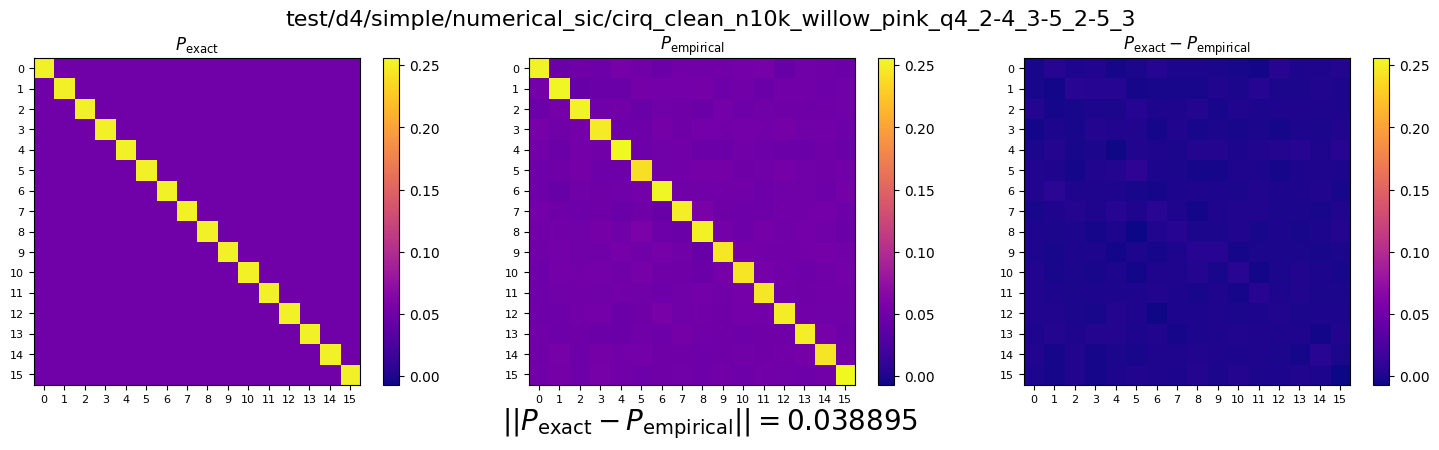

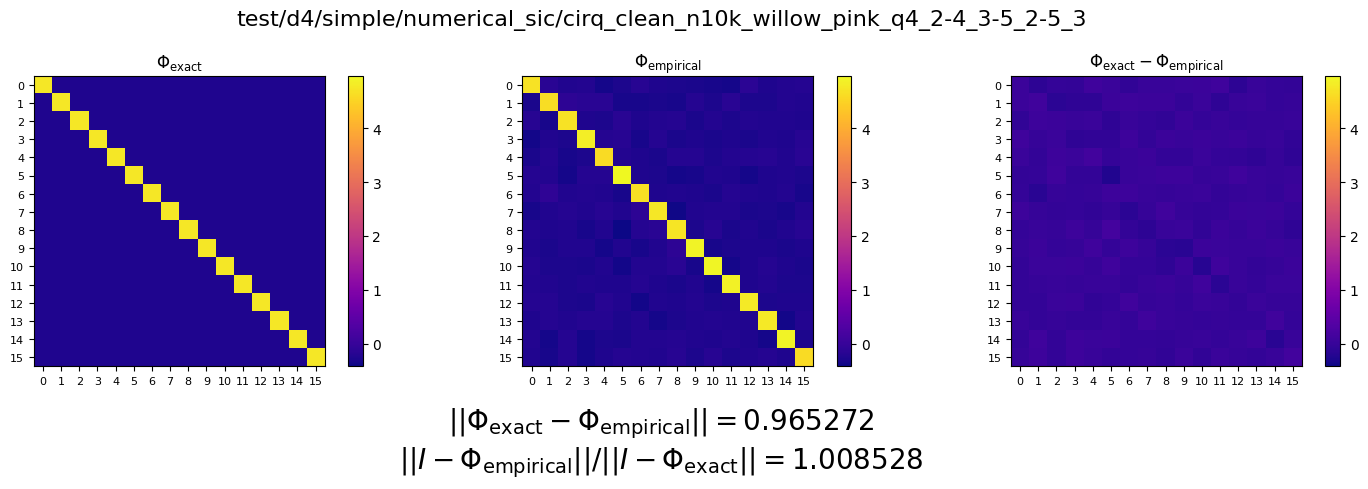

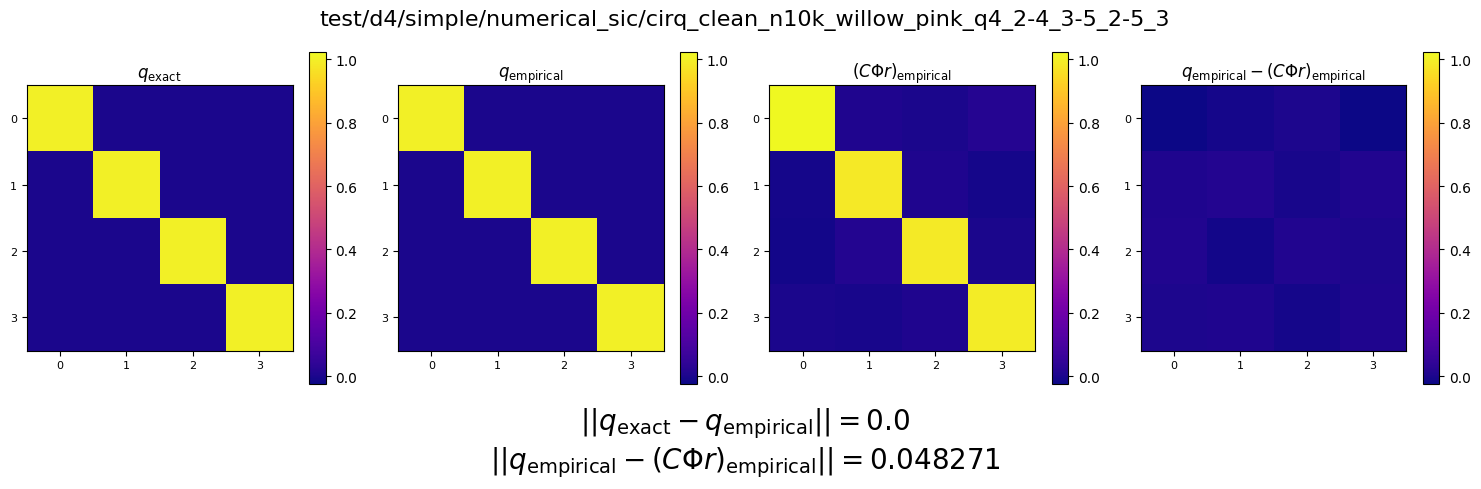

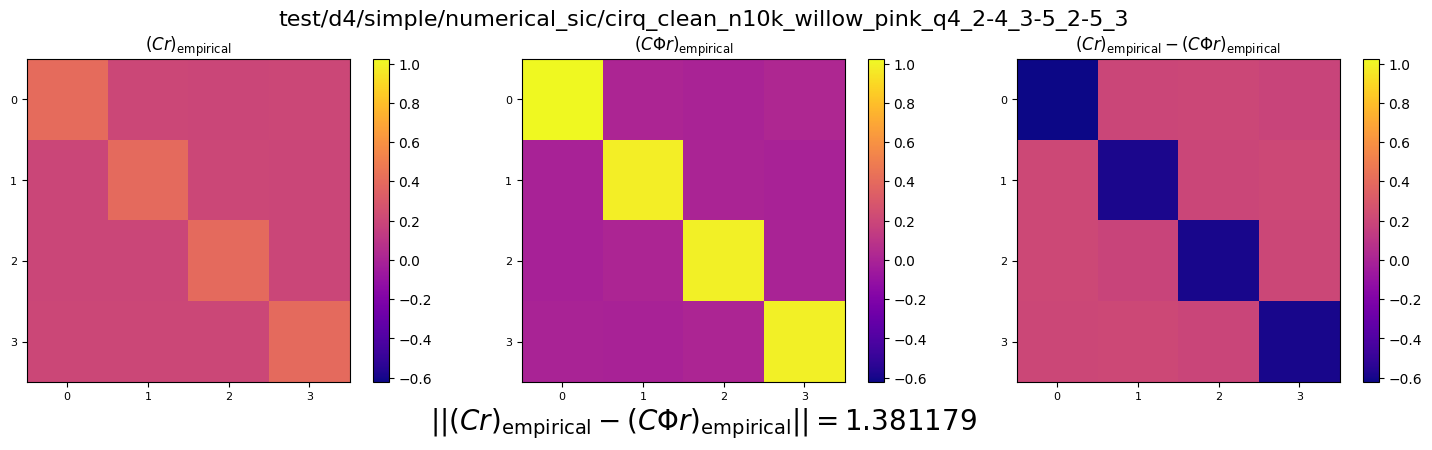

In [22]:
sky_ground_images(specs, img_dir="img", show=True)